# Model Training

## Import Required Libraries

In [7]:
import sys
import os
import pandas as pd
import numpy as np
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, auc
from sklearn.preprocessing import StandardScaler

import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, '../ml')
from src.features import engineer_features, get_feature_columns

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## Set Up Configuration

In [8]:
data_path = '../data/raw/'
model_path = '../ml/models/'
random_state = 42

train_file = os.path.join(data_path, 'fraudTrain.csv')
test_file = os.path.join(data_path, 'fraudTest.csv')

os.makedirs(model_path, exist_ok=True)

np.random.seed(random_state)

## Define Utility Functions

In [9]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
    pr_auc = auc(recall, precision)
    
    print(f"\n{model_name}")
    print("=" * 50)
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"PR-AUC: {pr_auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    return {'roc_auc': roc_auc, 'pr_auc': pr_auc, 'y_pred': y_pred, 'y_pred_proba': y_pred_proba}

def plot_confusion_matrices(results, y_test):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    for idx, (model_name, result) in enumerate(results.items()):
        cm = confusion_matrix(y_test, result['y_pred'])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False)
        axes[idx].set_title(model_name)
        axes[idx].set_ylabel('Actual')
        axes[idx].set_xlabel('Predicted')
    
    plt.tight_layout()
    plt.show()

def plot_roc_curves(results, y_test):
    from sklearn.metrics import roc_curve
    plt.figure(figsize=(8, 6))
    
    for model_name, result in results.items():
        fpr, tpr, _ = roc_curve(y_test, result['y_pred_proba'])
        plt.plot(fpr, tpr, label=f"{model_name} (AUC={result['roc_auc']:.4f})")
    
    plt.plot([0, 1], [0, 1], 'k--', label='Random')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

## Execute Main Workflow

### Load & Combine Data

In [22]:
df_train = pd.read_csv(train_file)
df_test = pd.read_csv(test_file)
df = pd.concat([df_train, df_test], ignore_index=True)

print(f"Training set: {df_train.shape[0]}")
print(f"Test set: {df_test.shape[0]}")
print(f"Combined: {df.shape[0]}")
print(f"Fraud rate: {df['is_fraud'].mean():.4%}")

Training set: 1296675
Test set: 555719
Combined: 1852394
Fraud rate: 0.5210%


### Engineer Features

In [23]:
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

df_engineered, encoders = engineer_features(df, fit_encoders=True)
feature_cols = get_feature_columns()

X = df_engineered[feature_cols].copy()
y = df['is_fraud'].copy()

print(f"Features shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts(normalize=True)}")

Features shape: (1852394, 17)
Target distribution:
is_fraud
0    0.99479
1    0.00521
Name: proportion, dtype: float64


### Prepare Training & Test Sets

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=random_state, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")
print(f"Train fraud rate: {y_train.mean():.4%}")
print(f"Test fraud rate: {y_test.mean():.4%}")

Train: 1296675, Test: 555719
Train fraud rate: 0.5210%
Test fraud rate: 0.5209%


### Train Models

In [25]:
lr = LogisticRegression(max_iter=1000, random_state=random_state, n_jobs=-1, class_weight='balanced')
lr.fit(X_train_scaled, y_train)

print("Logistic Regression trained")

Logistic Regression trained


In [26]:
rf = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=random_state, n_jobs=-1, class_weight='balanced')
rf.fit(X_train, y_train)

print("Random Forest trained")

Random Forest trained


In [27]:
xgb_model = xgb.XGBClassifier(
    n_estimators=100, max_depth=7, learning_rate=0.1, random_state=random_state,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(), n_jobs=-1
)
xgb_model.fit(X_train, y_train, verbose=False)

print("XGBoost trained")

XGBoost trained


### Evaluate Models

In [28]:
results = {}

results['Logistic Regression'] = evaluate_model(lr, X_test_scaled, y_test, 'Logistic Regression')
results['Random Forest'] = evaluate_model(rf, X_test, y_test, 'Random Forest')
results['XGBoost'] = evaluate_model(xgb_model, X_test, y_test, 'XGBoost')


Logistic Regression
ROC-AUC: 0.9451
PR-AUC: 0.2826

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.88      0.94    552824
           1       0.04      0.84      0.07      2895

    accuracy                           0.88    555719
   macro avg       0.52      0.86      0.50    555719
weighted avg       0.99      0.88      0.93    555719


Random Forest
ROC-AUC: 0.9964
PR-AUC: 0.8671

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    552824
           1       0.52      0.91      0.66      2895

    accuracy                           1.00    555719
   macro avg       0.76      0.95      0.83    555719
weighted avg       1.00      1.00      1.00    555719


XGBoost
ROC-AUC: 0.9989
PR-AUC: 0.9335

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00    552824
           1       0.35    

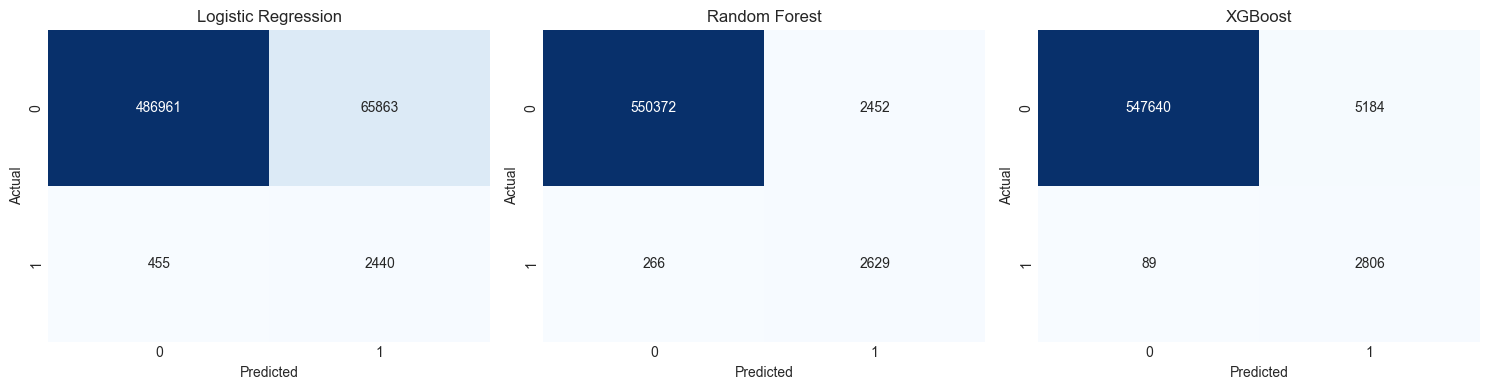

In [17]:
plot_confusion_matrices(results, y_test)

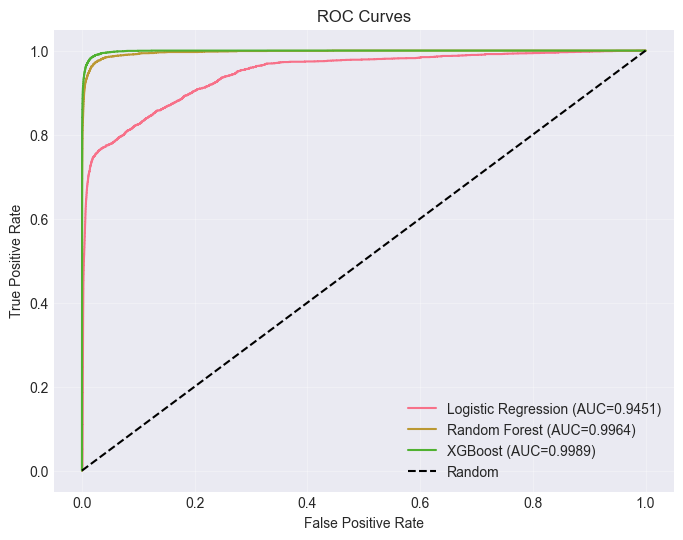

In [18]:
plot_roc_curves(results, y_test)

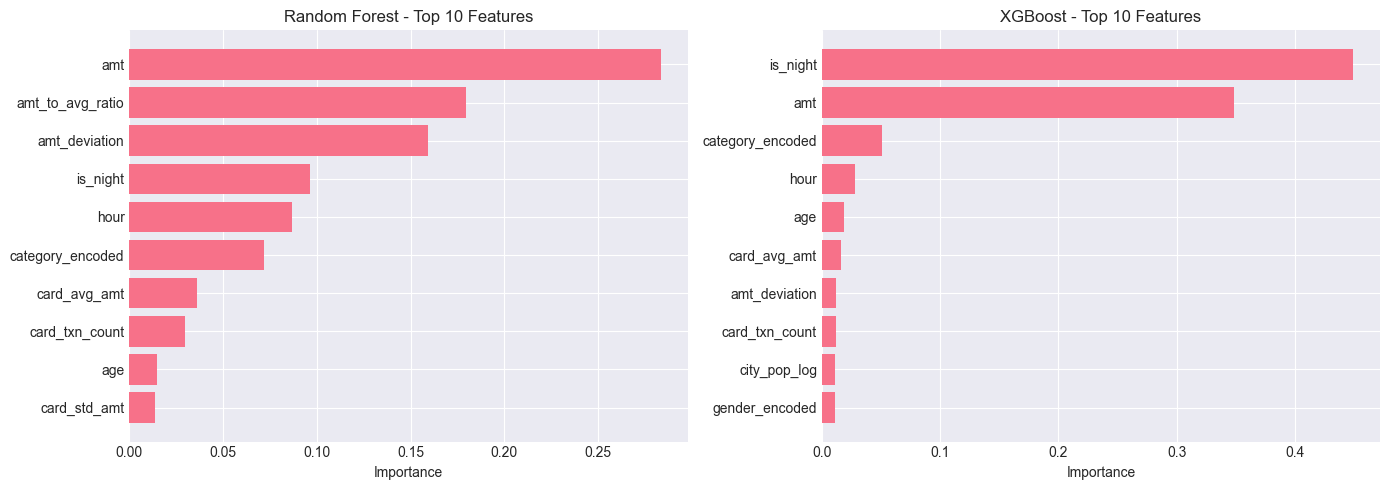

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rf_importance = rf.feature_importances_
xgb_importance = xgb_model.feature_importances_

rf_top = np.argsort(rf_importance)[-10:]
xgb_top = np.argsort(xgb_importance)[-10:]

axes[0].barh(range(10), rf_importance[rf_top])
axes[0].set_yticks(range(10))
axes[0].set_yticklabels([feature_cols[i] for i in rf_top])
axes[0].set_title('Random Forest - Top 10 Features')
axes[0].set_xlabel('Importance')

axes[1].barh(range(10), xgb_importance[xgb_top])
axes[1].set_yticks(range(10))
axes[1].set_yticklabels([feature_cols[i] for i in xgb_top])
axes[1].set_title('XGBoost - Top 10 Features')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

### Model Comparison & Save Best Model

In [29]:
comparison = pd.DataFrame({
    'Model': list(results.keys()),
    'ROC-AUC': [results[m]['roc_auc'] for m in results.keys()],
    'PR-AUC': [results[m]['pr_auc'] for m in results.keys()]
})

print("\nModel Comparison:")
print(comparison.to_string(index=False))

best_model_name = comparison.loc[comparison['ROC-AUC'].idxmax(), 'Model']
best_model = {'Logistic Regression': lr, 'Random Forest': rf, 'XGBoost': xgb_model}[best_model_name]

print(f"\nBest Model: {best_model_name}")


Model Comparison:
              Model  ROC-AUC   PR-AUC
Logistic Regression 0.945124 0.282576
      Random Forest 0.996450 0.867051
            XGBoost 0.998858 0.933542

Best Model: XGBoost


In [38]:
model_info = {
    'model': best_model,
    'scaler': scaler if best_model_name == 'Logistic Regression' else None,
    'encoders': encoders,
    'feature_columns': feature_cols,
    'decision_threshold': 0.80,
    'metrics': {
        'roc_auc': results[best_model_name]['roc_auc'],
        'pr_auc': results[best_model_name]['pr_auc'],
        'precision_at_threshold': 0.590761,
        'recall_at_threshold': 0.936442,
        'f1_at_threshold': 0.724479
    }
}

with open(os.path.join(model_path, f'{best_model_name.lower().replace(" ", "_")}_model.pkl'), 'wb') as f:
    pickle.dump(model_info, f)

print(f"Model saved to {model_path}")
print(f"ROC-AUC: {model_info['metrics']['roc_auc']:.4f}")
print(f"PR-AUC: {model_info['metrics']['pr_auc']:.4f}")
print(f"\nDecision Threshold: {model_info['decision_threshold']}")
print(f"Precision at threshold: {model_info['metrics']['precision_at_threshold']:.2%}")
print(f"Recall at threshold: {model_info['metrics']['recall_at_threshold']:.2%}")

Model saved to ../ml/models/
ROC-AUC: 0.9989
PR-AUC: 0.9335

Decision Threshold: 0.8
Precision at threshold: 59.08%
Recall at threshold: 93.64%


### Threshold Tuning - Precision vs Recall

 Threshold  Precision   Recall       F1
      0.10   0.118609 0.994473 0.211941
      0.15   0.152000 0.991019 0.263574
      0.20   0.182270 0.988601 0.307792
      0.25   0.210158 0.986183 0.346481
      0.30   0.237761 0.983074 0.382913
      0.35   0.264799 0.979620 0.416906
      0.40   0.291809 0.975820 0.449268
      0.45   0.319605 0.973057 0.481168
      0.50   0.351189 0.969257 0.515572
      0.55   0.386156 0.965458 0.551663
      0.60   0.421506 0.962694 0.586305
      0.65   0.459433 0.956477 0.620713
      0.70   0.498190 0.950950 0.653842
      0.75   0.542104 0.945078 0.688995
      0.80   0.590761 0.936442 0.724479
      0.85   0.655021 0.926079 0.767315
      0.90   0.739277 0.910881 0.816156


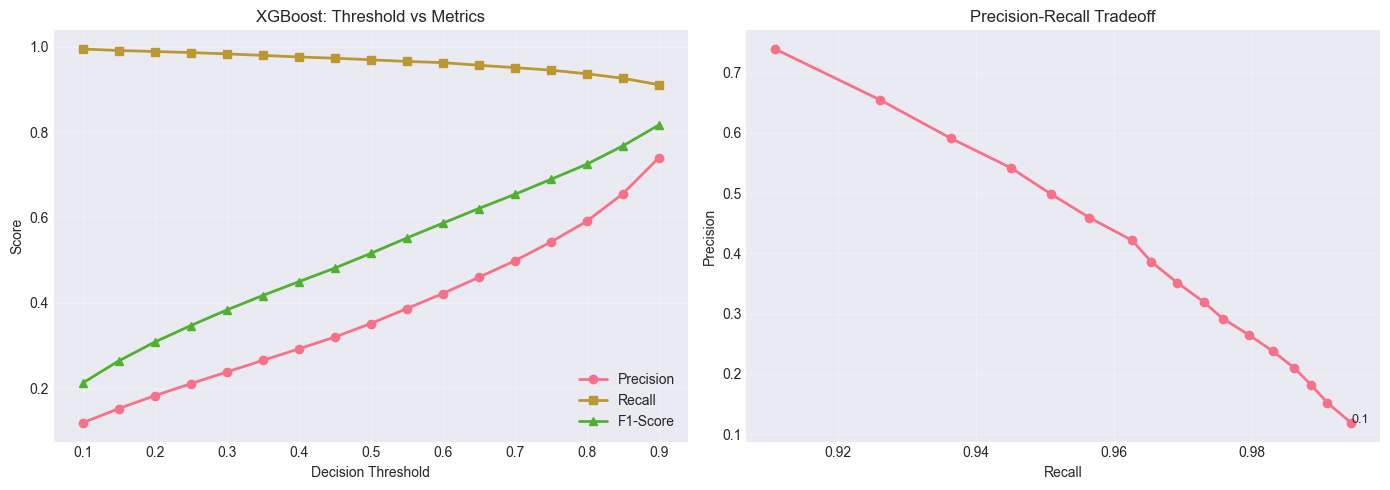


Optimal Threshold (by F1): 0.90
  Precision: 0.7393
  Recall: 0.9109


In [31]:
from sklearn.metrics import precision_score, recall_score, f1_score

y_pred_proba = results['XGBoost']['y_pred_proba']
thresholds = np.arange(0.1, 0.95, 0.05)

threshold_results = []
for thresh in thresholds:
    y_pred_thresh = (y_pred_proba > thresh).astype(int)
    precision = precision_score(y_test, y_pred_thresh, zero_division=0)
    recall = recall_score(y_test, y_pred_thresh, zero_division=0)
    f1 = f1_score(y_test, y_pred_thresh, zero_division=0)
    threshold_results.append({'Threshold': thresh, 'Precision': precision, 'Recall': recall, 'F1': f1})

threshold_df = pd.DataFrame(threshold_results)
print(threshold_df.to_string(index=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(threshold_df['Threshold'], threshold_df['Precision'], 'o-', label='Precision', linewidth=2)
ax1.plot(threshold_df['Threshold'], threshold_df['Recall'], 's-', label='Recall', linewidth=2)
ax1.plot(threshold_df['Threshold'], threshold_df['F1'], '^-', label='F1-Score', linewidth=2)
ax1.set_xlabel('Decision Threshold')
ax1.set_ylabel('Score')
ax1.set_title('XGBoost: Threshold vs Metrics')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(threshold_df['Recall'], threshold_df['Precision'], 'o-', linewidth=2)
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Tradeoff')
ax2.grid(alpha=0.3)

for idx, row in threshold_df.iterrows():
    if row['Threshold'] % 0.1 == 0:
        ax2.annotate(f"{row['Threshold']:.1f}", (row['Recall'], row['Precision']), fontsize=9)

plt.tight_layout()
plt.show()

best_f1_idx = threshold_df['F1'].idxmax()
print(f"\nOptimal Threshold (by F1): {threshold_df.loc[best_f1_idx, 'Threshold']:.2f}")
print(f"  Precision: {threshold_df.loc[best_f1_idx, 'Precision']:.4f}")
print(f"  Recall: {threshold_df.loc[best_f1_idx, 'Recall']:.4f}")